### Reading in Data, Basic Queries

In [230]:
import pandas as pd

In [231]:
df = pd.read_csv("data/gdp.csv")

In [232]:
df.head(5)

,Country,Code,Year,GDP (constant 2010 US$)
0,Afghanistan,AFG,2002,8.013233e+09
1,Afghanistan,AFG,2003,8.689884e+09
2,Afghanistan,AFG,2004,8.781610e+09
3,Afghanistan,AFG,2005,9.762979e+09
4,Afghanistan,AFG,2006,1.030523e+10


In [233]:
df.tail(5)

,Country,Code,Year,GDP (constant 2010 US$)
8864,Zimbabwe,ZWE,2013,1.418193e+10
8865,Zimbabwe,ZWE,2014,1.448359e+10
8866,Zimbabwe,ZWE,2015,1.472830e+10
8867,Zimbabwe,ZWE,2016,1.481899e+10
8868,Zimbabwe,ZWE,2017,1.532981e+10


In [234]:
df["gdp"] = df["GDP (constant 2010 US$)"] / 1_000_000_000

In [235]:
df.head(10)

,Country,Code,Year,GDP (constant 2010 US$),gdp
0,Afghanistan,AFG,2002,8.013233e+09,8.013233
1,Afghanistan,AFG,2003,8.689884e+09,8.689884
2,Afghanistan,AFG,2004,8.781610e+09,8.781610
3,Afghanistan,AFG,2005,9.762979e+09,9.762979
4,Afghanistan,AFG,2006,1.030523e+10,10.305228
5,Afghanistan,AFG,2007,1.172119e+10,11.721188
6,Afghanistan,AFG,2008,1.214448e+10,12.144483
7,Afghanistan,AFG,2009,1.469733e+10,14.697332
8,Afghanistan,AFG,2010,1.593680e+10,15.936801
9,Afghanistan,AFG,2011,1.691113e+10,16.911126


In [236]:
# See the GDP of only China
df[df["Country"] == "China"].head(20)

,Country,Code,Year,GDP (constant 2010 US$),gdp
1726,China,CHN,1960,1.279381e+11,127.938142
1727,China,CHN,1961,9.304941e+10,93.049411
1728,China,CHN,1962,8.785725e+10,87.857254
1729,China,CHN,1963,9.690655e+10,96.906551
1730,China,CHN,1964,1.145242e+11,114.524162
1731,China,CHN,1965,1.339360e+11,133.936007
1732,China,CHN,1966,1.482002e+11,148.200192
1733,China,CHN,1967,1.396490e+11,139.649041
1734,China,CHN,1968,1.339234e+11,133.923430
1735,China,CHN,1969,1.566101e+11,156.610060


In [237]:
# GDP of China in 2017 using &
df[(df["Country"] == "China") & (df["Year"] == 2017)]

,Country,Code,Year,GDP (constant 2010 US$),gdp
1783,China,CHN,2017,1.016101e+13,10161.012759


In [238]:
# GDP of China in 2017 using query 
df.query('Country == "China" and Year == 2017')

,Country,Code,Year,GDP (constant 2010 US$),gdp
1783,China,CHN,2017,1.016101e+13,10161.012759


In [239]:
# Seeing GDP only from a list of countries using isin
list_of_countries = ["China", "United States", "India",
                     "Japan", "Germany", "United Kingdom"]
top6 = df[df["Country"].isin(list_of_countries)]
top6.head()

,Country,Code,Year,GDP (constant 2010 US$),gdp
1726,China,CHN,1960,1.279381e+11,127.938142
1727,China,CHN,1961,9.304941e+10,93.049411
1728,China,CHN,1962,8.785725e+10,87.857254
1729,China,CHN,1963,9.690655e+10,96.906551
1730,China,CHN,1964,1.145242e+11,114.524162


In [240]:
top6 = df.query("Country in @list_of_countries and Year == 2017")
top6.head()

,Country,Code,Year,GDP (constant 2010 US$),gdp
1783,China,CHN,2017,1.016101e+13,10161.012759
3130,Germany,DEU,2017,3.865759e+12,3865.759081
3789,India,IND,2017,2.629542e+12,2629.542212
4261,Japan,JPN,2017,6.156329e+12,6156.328721
8436,United Kingdom,GBR,2017,2.806903e+12,2806.903097


### Introducing Our Visualization Libraries

In [241]:
import matplotlib.pyplot as plt

<Axes: xlabel='Country'>

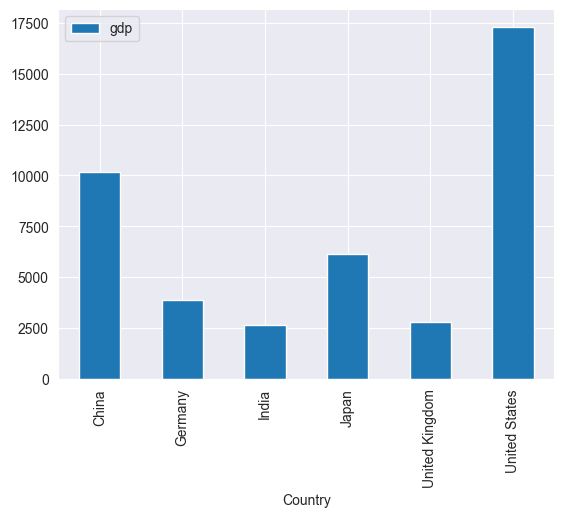

In [242]:
top6.plot(x="Country", y="gdp", kind="bar")

<Axes: xlabel='Country', ylabel='gdp'>

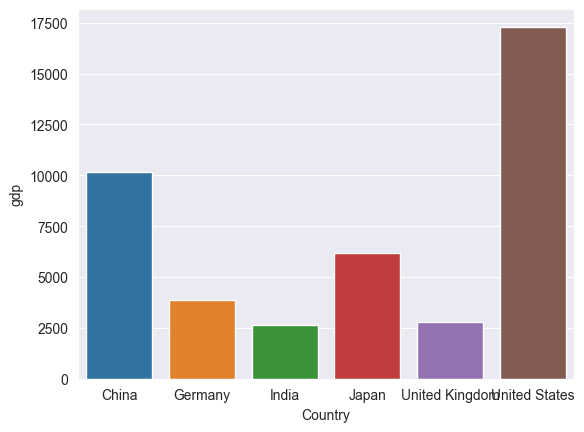

In [243]:
import seaborn as sns

sns.barplot(data=top6, x="Country", y="gdp")

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'China'),
  Text(1, 0, 'Germany'),
  Text(2, 0, 'India'),
  Text(3, 0, 'Japan'),
  Text(4, 0, 'United Kingdom'),
  Text(5, 0, 'United States')])

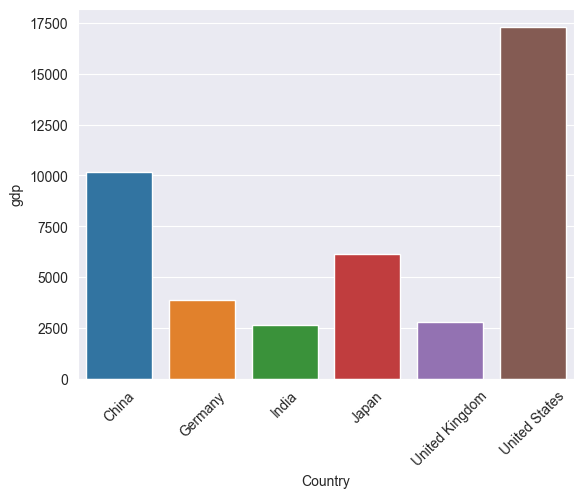

In [244]:
sns.barplot(data=top6, x="Country", y="gdp")
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'China'),
  Text(1, 0, 'Germany'),
  Text(2, 0, 'India'),
  Text(3, 0, 'Japan'),
  Text(4, 0, 'United Kingdom'),
  Text(5, 0, 'United States')])

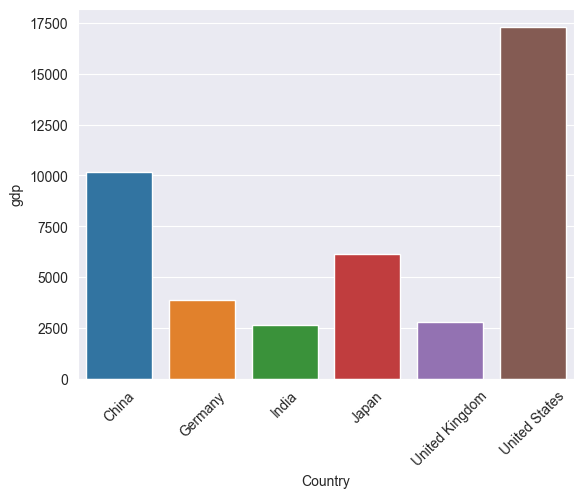

In [245]:
import seaborn as sns

sns.barplot(data=top6, x="Country", y="gdp")
plt.xticks(rotation=45)

In [246]:
import plotly.express as px

fig = px.bar(top6, x="Country", y="gdp", color="Country", color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [247]:
list_of_countries = ["China", "United States", "India", "Japan", "Germany", "United Kingdom"]
top6_over_time = df[df["Country"].isin(list_of_countries)]

fig = px.line(top6_over_time, x="Year", y="gdp", color="Country", title="Top 6 Country GDP (in billions)", color_discrete_sequence=px.colors.qualitative.G10)
fig.update_layout(font_size=16)

fig.show()

### Groupby Operations

###### What was the total GDP of the world in each year?

In [248]:
df.query("Year == 1960").head(20)

,Country,Code,Year,GDP (constant 2010 US$),gdp
54,Algeria,DZA,1960,2.743440e+10,27.434399
254,Argentina,ARG,1960,1.155739e+11,115.573869
341,Australia,AUS,1960,1.992333e+11,199.233335
399,Austria,AUT,1960,9.183670e+10,91.836703
485,Bahamas,BHS,1960,1.942538e+09,1.942538
581,Bangladesh,BGD,1960,1.786255e+10,17.862545
711,Belgium,BEL,1960,1.207649e+11,120.764863
769,Belize,BLZ,1960,9.873554e+07,0.098736
827,Benin,BEN,1960,1.265426e+09,1.265426
885,Bermuda,BMU,1960,1.236025e+09,1.236025


In [249]:
df.groupby("Year").agg(sum).head(30)

C:\Users\Plamen\AppData\Local\Temp\ipykernel_22104\3634946134.py:1: FutureWarning:

The operation <built-in function sum> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.



,GDP (constant 2010 US$),gdp
Year,,
1960,9.025835e+12,9025.834854
1961,9.434022e+12,9434.021757
1962,9.959005e+12,9959.004555
1963,1.047782e+13,10477.823331
1964,1.117623e+13,11176.230223
1965,1.181914e+13,11819.143945
1966,1.252228e+13,12522.277252
1967,1.307806e+13,13078.059822
1968,1.397970e+13,13979.698343


In [250]:
px.line(df.groupby("Year")["gdp"].agg(sum))

###### What was the largest GDP of any country in each year?

In [251]:
px.line(df.groupby("Year")[["gdp"]].agg(max))

###### What was the smallest GDP of any country in each year?

In [252]:
px.line(df.groupby("Year")[["gdp"]].agg(min))

###### What was the ratio of the largest to smallest GDP in each year?

In [253]:
largest_gdps = df.groupby("Year")[["gdp"]].agg(max)
smallest_gdps = df.groupby("Year")[["gdp"]].agg(min)

In [254]:
ratio_of_largest_to_smallest = largest_gdps / smallest_gdps

In [255]:
ratio_of_largest_to_smallest

,gdp
Year,
1960,31174.904577
1961,30404.457057
1962,30754.422037
1963,30591.375224
1964,30824.487623
1965,31256.157197
1966,31772.013845
1967,31427.624080
1968,30923.144291


In [256]:
def ratio_of_largest_to_smallest(s):
    largest=max(s)
    smallest=round(min(s), 10)
    result=(largest/smallest)
    return result

df.groupby("Year")[["gdp"]].agg(ratio_of_largest_to_smallest)

,gdp
Year,
1960,31174.904567
1961,30404.457046
1962,30754.422024
1963,30591.375216
1964,30824.487622
1965,31256.157209
1966,31772.013857
1967,31427.624087
1968,30923.144300


In [257]:
#df.groupby("Country").agg(ratio_of_largest_to_smallest)
ratio_of_largest_to_smallest

<function __main__.ratio_of_largest_to_smallest(s)>

###### What was the smallest economy in each year?

In [258]:
df.groupby("Year").agg(min).head(30)

,Country,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,Algeria,ARG,9.873554e+07,0.098736
1961,Algeria,ARG,1.035660e+08,0.103566
1962,Algeria,ARG,1.086331e+08,0.108633
1963,Algeria,ARG,1.140174e+08,0.114017
1964,Algeria,ARG,1.197181e+08,0.119718
1965,Algeria,ARG,1.256209e+08,0.125621
1966,Algeria,ARG,1.316141e+08,0.131614
1967,Algeria,ARG,1.363827e+08,0.136383
1968,Algeria,ARG,1.452608e+08,0.145261


In [259]:
df.sort_values("gdp").head(30)

,Country,Code,Year,GDP (constant 2010 US$),gdp
8241,Tuvalu,TUV,1990,2.144197e+07,0.021442
8242,Tuvalu,TUV,1991,2.221584e+07,0.022216
8243,Tuvalu,TUV,1992,2.283541e+07,0.022835
8247,Tuvalu,TUV,1996,2.342202e+07,0.023422
8244,Tuvalu,TUV,1993,2.377411e+07,0.023774
8246,Tuvalu,TUV,1995,2.490680e+07,0.024907
8248,Tuvalu,TUV,1997,2.576498e+07,0.025765
8245,Tuvalu,TUV,1994,2.621891e+07,0.026219
8251,Tuvalu,TUV,2000,2.900917e+07,0.029009
8256,Tuvalu,TUV,2005,2.918573e+07,0.029186


In [260]:
def get_first_item(s):
    return s.iloc[0]

In [261]:
df.sort_values("gdp").groupby("Year").agg(get_first_item)

,Country,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,Belize,BLZ,9.873554e+07,0.098736
1961,Belize,BLZ,1.035660e+08,0.103566
1962,Belize,BLZ,1.086331e+08,0.108633
1963,Belize,BLZ,1.140174e+08,0.114017
1964,Belize,BLZ,1.197181e+08,0.119718
1965,Belize,BLZ,1.256209e+08,0.125621
1966,Belize,BLZ,1.316141e+08,0.131614
1967,Saint Vincent and the Grenadines,VCT,1.363827e+08,0.136383
1968,Saint Vincent and the Grenadines,VCT,1.452608e+08,0.145261


In [262]:
df.sort_values("gdp").groupby("Year").first()

,Country,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,Belize,BLZ,9.873554e+07,0.098736
1961,Belize,BLZ,1.035660e+08,0.103566
1962,Belize,BLZ,1.086331e+08,0.108633
1963,Belize,BLZ,1.140174e+08,0.114017
1964,Belize,BLZ,1.197181e+08,0.119718
1965,Belize,BLZ,1.256209e+08,0.125621
1966,Belize,BLZ,1.316141e+08,0.131614
1967,Saint Vincent and the Grenadines,VCT,1.363827e+08,0.136383
1968,Saint Vincent and the Grenadines,VCT,1.452608e+08,0.145261


In [263]:
df[df["Country"] == "Tuvalu"]

,Country,Code,Year,GDP (constant 2010 US$),gdp
8241,Tuvalu,TUV,1990,2.144197e+07,0.021442
8242,Tuvalu,TUV,1991,2.221584e+07,0.022216
8243,Tuvalu,TUV,1992,2.283541e+07,0.022835
8244,Tuvalu,TUV,1993,2.377411e+07,0.023774
8245,Tuvalu,TUV,1994,2.621891e+07,0.026219
8246,Tuvalu,TUV,1995,2.490680e+07,0.024907
8247,Tuvalu,TUV,1996,2.342202e+07,0.023422
8248,Tuvalu,TUV,1997,2.576498e+07,0.025765
8249,Tuvalu,TUV,1998,2.975886e+07,0.029759
8250,Tuvalu,TUV,1999,2.929350e+07,0.029293


###### What fraction of world GDP did each country generate each year?

In [264]:
df.head(30)

,Country,Code,Year,GDP (constant 2010 US$),gdp
0,Afghanistan,AFG,2002,8.013233e+09,8.013233
1,Afghanistan,AFG,2003,8.689884e+09,8.689884
2,Afghanistan,AFG,2004,8.781610e+09,8.781610
3,Afghanistan,AFG,2005,9.762979e+09,9.762979
4,Afghanistan,AFG,2006,1.030523e+10,10.305228
5,Afghanistan,AFG,2007,1.172119e+10,11.721188
6,Afghanistan,AFG,2008,1.214448e+10,12.144483
7,Afghanistan,AFG,2009,1.469733e+10,14.697332
8,Afghanistan,AFG,2010,1.593680e+10,15.936801
9,Afghanistan,AFG,2011,1.691113e+10,16.911126


In [265]:
total_gdp = df.gdp.sum()

In [266]:
chinese_gdp_indexed_by_year = df.query('Country == "China"').set_index("Year")

In [267]:
chinese_gdp_indexed_by_year.head(30)

,Country,Code,GDP (constant 2010 US$),gdp
Year,,,,
1960,China,CHN,1.279381e+11,127.938142
1961,China,CHN,9.304941e+10,93.049411
1962,China,CHN,8.785725e+10,87.857254
1963,China,CHN,9.690655e+10,96.906551
1964,China,CHN,1.145242e+11,114.524162
1965,China,CHN,1.339360e+11,133.936007
1966,China,CHN,1.482002e+11,148.200192
1967,China,CHN,1.396490e+11,139.649041
1968,China,CHN,1.339234e+11,133.923430


In [268]:
chinese_gdp_indexed_by_year.gdp / total_gdp

Year
1960    0.000059
1961    0.000043
1962    0.000040
1963    0.000045
1964    0.000053
1965    0.000062
1966    0.000068
1967    0.000064
1968    0.000062
1969    0.000072
1970    0.000086
1971    0.000092
1972    0.000095
1973    0.000103
1974    0.000105
1975    0.000114
1976    0.000113
1977    0.000121
1978    0.000135
1979    0.000145
1980    0.000157
1981    0.000165
1982    0.000180
1983    0.000199
1984    0.000229
1985    0.000260
1986    0.000283
1987    0.000316
1988    0.000352
1989    0.000367
1990    0.000381
1991    0.000416
1992    0.000476
1993    0.000541
1994    0.000612
1995    0.000679
1996    0.000747
1997    0.000816
1998    0.000879
1999    0.000947
2000    0.001027
2001    0.001113
2002    0.001215
2003    0.001336
2004    0.001472
2005    0.001639
2006    0.001848
2007    0.002111
2008    0.002315
2009    0.002532
2010    0.002802
2011    0.003069
2012    0.003310
2013    0.003567
2014    0.003827
2015    0.004091
2016    0.004365
2017    0.004666
Name: gdp

In [269]:
px.line((chinese_gdp_indexed_by_year.gdp / total_gdp))

In [270]:
df.set_index("Year").head(30)

,Country,Code,GDP (constant 2010 US$),gdp
Year,,,,
2002,Afghanistan,AFG,8.013233e+09,8.013233
2003,Afghanistan,AFG,8.689884e+09,8.689884
2004,Afghanistan,AFG,8.781610e+09,8.781610
2005,Afghanistan,AFG,9.762979e+09,9.762979
2006,Afghanistan,AFG,1.030523e+10,10.305228
2007,Afghanistan,AFG,1.172119e+10,11.721188
2008,Afghanistan,AFG,1.214448e+10,12.144483
2009,Afghanistan,AFG,1.469733e+10,14.697332
2010,Afghanistan,AFG,1.593680e+10,15.936801


In [271]:
#df.set_index("Year") / total_gdp

In [272]:
df_indexed_by_year_and_entity = df.set_index(["Year", "Country"])
df_indexed_by_year_and_entity.head(30)

,,Code,GDP (constant 2010 US$),gdp
Year,Country,,,
2002,Afghanistan,AFG,8.013233e+09,8.013233
2003,Afghanistan,AFG,8.689884e+09,8.689884
2004,Afghanistan,AFG,8.781610e+09,8.781610
2005,Afghanistan,AFG,9.762979e+09,9.762979
2006,Afghanistan,AFG,1.030523e+10,10.305228
2007,Afghanistan,AFG,1.172119e+10,11.721188
2008,Afghanistan,AFG,1.214448e+10,12.144483
2009,Afghanistan,AFG,1.469733e+10,14.697332
2010,Afghanistan,AFG,1.593680e+10,15.936801


In [273]:
share_of_world_economy_by_year_and_entity = (df_indexed_by_year_and_entity.gdp / total_gdp)
share_of_world_economy_by_year_and_entity.head(30)

Year  Country    
2002  Afghanistan    0.000004
2003  Afghanistan    0.000004
2004  Afghanistan    0.000004
2005  Afghanistan    0.000004
2006  Afghanistan    0.000005
2007  Afghanistan    0.000005
2008  Afghanistan    0.000006
2009  Afghanistan    0.000007
2010  Afghanistan    0.000007
2011  Afghanistan    0.000008
2012  Afghanistan    0.000009
2013  Afghanistan    0.000009
2014  Afghanistan    0.000009
2015  Afghanistan    0.000010
2016  Afghanistan    0.000010
2017  Afghanistan    0.000010
1980  Albania        0.000003
1981  Albania        0.000003
1982  Albania        0.000003
1983  Albania        0.000003
1984  Albania        0.000003
1985  Albania        0.000003
1986  Albania        0.000003
1987  Albania        0.000003
1988  Albania        0.000003
1989  Albania        0.000003
1990  Albania        0.000003
1991  Albania        0.000002
1992  Albania        0.000002
1993  Albania        0.000002
Name: gdp, dtype: float64

In [274]:
share_of_world_economy = share_of_world_economy_by_year_and_entity.reset_index()
share_of_world_economy.head(30)

,Year,Country,gdp
0,2002,Afghanistan,0.000004
1,2003,Afghanistan,0.000004
2,2004,Afghanistan,0.000004
3,2005,Afghanistan,0.000004
4,2006,Afghanistan,0.000005
5,2007,Afghanistan,0.000005
6,2008,Afghanistan,0.000006
7,2009,Afghanistan,0.000007
8,2010,Afghanistan,0.000007
9,2011,Afghanistan,0.000008


In [275]:
top6_share = share_of_world_economy[share_of_world_economy["Country"].isin(list_of_countries)]
top6_share.head(30)

,Year,Country,gdp
1726,1960,China,0.000059
1727,1961,China,0.000043
1728,1962,China,0.000040
1729,1963,China,0.000045
1730,1964,China,0.000053
1731,1965,China,0.000062
1732,1966,China,0.000068
1733,1967,China,0.000064
1734,1968,China,0.000062
1735,1969,China,0.000072


In [276]:
px.line(top6_share, x="Year", y="gdp", color="Country")

###### By what factor has each country’s GDP grown since 1960?

In [277]:
top6_all_time = df.query("Country in @list_of_countries")
top6_all_time.groupby("Country")

In [278]:
top6_by_entity_and_year = top6_all_time.set_index(["Country", "Year"])
top6_by_entity_and_year.head(30)

Code  GDP (constant 2010 US$)         gdp
Country Year                                          
China   1960  CHN             1.279381e+11  127.938142
        1961  CHN             9.304941e+10   93.049411
        1962  CHN             8.785725e+10   87.857254
        1963  CHN             9.690655e+10   96.906551
        1964  CHN             1.145242e+11  114.524162
        1965  CHN             1.339360e+11  133.936007
        1966  CHN             1.482002e+11  148.200192
        1967  CHN             1.396490e+11  139.649041
        1968  CHN             1.339234e+11  133.923430
        1969  CHN             1.566101e+11  156.610060
        1970  CHN             1.868358e+11  186.835801
        1971  CHN             2.000264e+11  200.026409
        1972  CHN             2.076474e+11  207.647415
        1973  CHN             2.237609e+11  223.760854
        1974  CHN             2.289297e+11  228.929730
        1975  CHN             2.488924e+11  248.892402
        1976  CHN             2.449848e+11  244.984792
        1977  CHN             2.635301e+11  263.530140
        1978  CHN             2.942753e+11  294.275264
        1979  CHN             3.166402e+11  316.640184
        1980  CHN             3.413593e+11  341.359306
        1981  CHN             3.590158e+11  359.015822
        1982  CHN             3.910918e+11  391.091825
        1983  CHN             4.334675e+11  433.467463
        1984  CHN             4.990908e+11  499.090847
        1985  CHN             5.661856e+11  566.185607
        1986  CHN             6.168010e+11  616.800952
        1987  CHN             6.888984e+11  688.898392
        1988  CHN             7.662928e+11  766.292786
        1989  CHN             7.983688e+11  798.368790

In [279]:
top6_all_time.groupby("Country").first()

,Code,Year,GDP (constant 2010 US$),gdp
Country,,,,
China,CHN,1960,1.279381e+11,127.938142
Germany,DEU,1970,1.534053e+12,1534.052735
India,IND,1960,1.367463e+11,136.746336
Japan,JPN,1960,7.962132e+11,796.213204
United Kingdom,GBR,1960,7.245584e+11,724.558361
United States,USA,1960,3.078071e+12,3078.071080


In [280]:
gdp1960_values_by_entity = top6_all_time.query("Year == 1960").set_index(["Country"])
gdp1960_values_by_entity

,Code,Year,GDP (constant 2010 US$),gdp
Country,,,,
China,CHN,1960,1.279381e+11,127.938142
India,IND,1960,1.367463e+11,136.746336
Japan,JPN,1960,7.962132e+11,796.213204
United Kingdom,GBR,1960,7.245584e+11,724.558361
United States,USA,1960,3.078071e+12,3078.071080


In [298]:
top6_by_entity_and_year["gdp_ratio"] = top6_by_entity_and_year["gdp"] / gdp1960_values_by_entity["gdp"]
top6_by_entity_and_year.head(30)

Code  GDP (constant 2010 US$)         gdp  gdp_ratio
Country Year                                                     
China   1960  CHN             1.279381e+11  127.938142   1.000000
        1961  CHN             9.304941e+10   93.049411   0.727300
        1962  CHN             8.785725e+10   87.857254   0.686717
        1963  CHN             9.690655e+10   96.906551   0.757448
        1964  CHN             1.145242e+11  114.524162   0.895153
        1965  CHN             1.339360e+11  133.936007   1.046881
        1966  CHN             1.482002e+11  148.200192   1.158374
        1967  CHN             1.396490e+11  139.649041   1.091536
        1968  CHN             1.339234e+11  133.923430   1.046783
        1969  CHN             1.566101e+11  156.610060   1.224108
        1970  CHN             1.868358e+11  186.835801   1.460360
        1971  CHN             2.000264e+11  200.026409   1.563462
        1972  CHN             2.076474e+11  207.647415   1.623030
        1973  CHN             2.237609e+11  223.760854   1.748977
        1974  CHN             2.289297e+11  228.929730   1.789378
        1975  CHN             2.488924e+11  248.892402   1.945412
        1976  CHN             2.449848e+11  244.984792   1.914869
        1977  CHN             2.635301e+11  263.530140   2.059825
        1978  CHN             2.942753e+11  294.275264   2.300137
        1979  CHN             3.166402e+11  316.640184   2.474947
        1980  CHN             3.413593e+11  341.359306   2.668159
        1981  CHN             3.590158e+11  359.015822   2.806167
        1982  CHN             3.910918e+11  391.091825   3.056882
        1983  CHN             4.334675e+11  433.467463   3.388102
        1984  CHN             4.990908e+11  499.090847   3.901032
        1985  CHN             5.661856e+11  566.185607   4.425464
        1986  CHN             6.168010e+11  616.800952   4.821087
        1987  CHN             6.888984e+11  688.898392   5.384621
        1988  CHN             7.662928e+11  766.292786   5.989557
        1989  CHN             7.983688e+11  798.368790   6.240272

In [299]:
top6_by_entity_and_year.groupby("Country")['gdp_ratio'].sum()

Country
China             969.850767
Germany             0.000000
India             300.461676
Japan             284.749889
United Kingdom    131.675567
United States     175.855552
Name: gdp_ratio, dtype: float64

In [282]:
top6_including_gdp_ratio = top6_by_entity_and_year.reset_index()

In [297]:
px.line(top6_including_gdp_ratio[top6_including_gdp_ratio.gdp_ratio > 0], x="Year", y="gdp_ratio", color="Country")

###### Plot only the countries with large gdp growth since 1960

In [284]:
df_by_entity_and_year = df.set_index(["Country", "Year"])
gdp1960_values_by_entity = df.query("Year == 1960").set_index(["Country"])
df_by_entity_and_year["gdp_ratio"] = df_by_entity_and_year["gdp"] / gdp1960_values_by_entity["gdp"]
df_with_gdp_ratio = df_by_entity_and_year.reset_index()
df_with_gdp_ratio.head(30)

,Country,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
0,Afghanistan,2002,AFG,8.013233e+09,8.013233,NaN
1,Afghanistan,2003,AFG,8.689884e+09,8.689884,NaN
2,Afghanistan,2004,AFG,8.781610e+09,8.781610,NaN
3,Afghanistan,2005,AFG,9.762979e+09,9.762979,NaN
4,Afghanistan,2006,AFG,1.030523e+10,10.305228,NaN
5,Afghanistan,2007,AFG,1.172119e+10,11.721188,NaN
6,Afghanistan,2008,AFG,1.214448e+10,12.144483,NaN
7,Afghanistan,2009,AFG,1.469733e+10,14.697332,NaN
8,Afghanistan,2010,AFG,1.593680e+10,15.936801,NaN
9,Afghanistan,2011,AFG,1.691113e+10,16.911126,NaN


In [285]:
df_with_gdp_ratio = df_with_gdp_ratio.dropna()
df_with_gdp_ratio.head(30)

,Country,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
54,Algeria,1960,DZA,2.743440e+10,27.434399,1.000000
55,Algeria,1961,DZA,2.370183e+10,23.701828,0.863946
56,Algeria,1962,DZA,1.903611e+10,19.036113,0.693878
57,Algeria,1963,DZA,2.556811e+10,25.568114,0.931973
58,Algeria,1964,DZA,2.706114e+10,27.061141,0.986395
59,Algeria,1965,DZA,2.874080e+10,28.740799,1.047619
60,Algeria,1966,DZA,2.735981e+10,27.359812,0.997281
61,Algeria,1967,DZA,2.994612e+10,29.946125,1.091554
62,Algeria,1968,DZA,3.317918e+10,33.179180,1.209401
63,Algeria,1969,DZA,3.597727e+10,35.977273,1.311393


In [286]:
px.line(df_with_gdp_ratio, x="Year", y="gdp_ratio", color="Country")

In [287]:
df_with_gdp_ratio.query("Year == 2017 and gdp_ratio > 10")

,Country,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
638,Bangladesh,2017,BGD,1.799922e+11,179.992152,10.076512
826,Belize,2017,BLZ,1.616833e+09,1.616833,16.375388
1116,Botswana,2017,BWA,1.724066e+10,17.240661,84.096474
1314,Burkina Faso,2017,BFA,1.321529e+10,13.215294,11.456717
1783,China,2017,CHN,1.016101e+13,10161.012759,79.421294
1841,Colombia,2017,COL,3.729359e+11,372.935922,10.224493
1995,Costa Rica,2017,CRI,4.803727e+10,48.037269,12.615259
2409,Dominican Republic,2017,DOM,7.701718e+10,77.017184,17.620514
2525,Egypt,2017,EGY,2.717216e+11,271.721622,15.947716
3789,India,2017,IND,2.629542e+12,2629.542212,19.229343


In [288]:
def max_gdp_ratio_gt_10(s):
    max_gdp_ratio = max(s["gdp_ratio"])
    return max_gdp_ratio > 10

In [289]:
ratio_greater_than_10 = df_with_gdp_ratio.groupby("Country").filter(max_gdp_ratio_gt_10)
ratio_greater_than_10.head(30)

,Country,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
581,Bangladesh,1960,BGD,1.786255e+10,17.862545,1.000000
582,Bangladesh,1961,BGD,1.894469e+10,18.944687,1.060582
583,Bangladesh,1962,BGD,1.997775e+10,19.977747,1.118415
584,Bangladesh,1963,BGD,1.988667e+10,19.886669,1.113317
585,Bangladesh,1964,BGD,2.206481e+10,22.064814,1.235256
586,Bangladesh,1965,BGD,2.241923e+10,22.419232,1.255097
587,Bangladesh,1966,BGD,2.299469e+10,22.994692,1.287313
588,Bangladesh,1967,BGD,2.256334e+10,22.563342,1.263165
589,Bangladesh,1968,BGD,2.470448e+10,24.704480,1.383032
590,Bangladesh,1969,BGD,2.500609e+10,25.006087,1.399917


In [290]:
px.line(ratio_greater_than_10, y="gdp_ratio", x="Year", color="Country")

In [291]:
ec = ["China", "India", "United States"]
ey = [1960, 1990, 2017]
df_with_gdp_ratio.query("Country in @ec and Year in @ey")

,Country,Year,Code,GDP (constant 2010 US$),gdp,gdp_ratio
1726,China,1960,CHN,1.279381e+11,127.938142,1.000000
1756,China,1990,CHN,8.295620e+11,829.561968,6.484086
1783,China,2017,CHN,1.016101e+13,10161.012759,79.421294
3732,India,1960,IND,1.367463e+11,136.746336,1.000000
3762,India,1990,IND,4.665332e+11,466.533191,3.411669
3789,India,2017,IND,2.629542e+12,2629.542212,19.229343
8437,United States,1960,USA,3.078071e+12,3078.071080,1.000000
8467,United States,1990,USA,9.064414e+12,9064.413765,2.944836
8494,United States,2017,USA,1.730498e+13,17304.984279,5.622022
